특성 데이터 ($\mathbf{X}$): alcohol, malic_acid 등의 13가지 화학적 수치

타겟 ($\mathbf{y}$): 0, 1, 2 (와인 종류를 나타내는 레이블)

- 0,class_0,와인 품종 1 (이탈리아 같은 지역의 품종)
- 1,class_1,와인 품종 2 (이탈리아 같은 지역의 품종)
- 2,class_2,와인 품종 3 (이탈리아 같은 지역의 품종)


| 특성 이름 (Feature Name) | 설명 (Description) | 단위 / 형식 | 중요도 (일반적) |
| --- | --- | --- | --- |
| **alcohol** | 알코올 함량 | % vol (볼륨 기준) | 높음 |
| **malic_acid** | 말산 함량 | g/L | 보통 |
| **ash** | 회분 (재) 함량 | g/L | 낮음 |
| **alcalinity_of_ash** | 회분의 알칼리도 (Ph) | pH 값 | 보통 |
| **magnesium** | 마그네슘 함량 | mg/L | 보통 |
| **total_phenols** | 총 페놀류 함량 (항산화 물질) | - | 높음 |
| **flavanoids** | 플라보노이드 함량 (페놀류의 일종) | - | **매우 높음** |
| **nonflavanoid_phenols** | 비(非) 플라보노이드 페놀류 함량 | - | 낮음 |
| **proanthocyanins** | 프로안토시아닌 함량 (탄닌 성분) | - | 보통 |
| **color_intensity** | 색상의 강도 (색이 진한 정도) | - | 높음 |
| **hue** | 색상 (채도, 특정 파장에서의 색조) | - | 높음 |
| **od280/od315_of_diluted_wines** | 희석된 와인에서 280nm와 315nm 파장 흡광도의 비율. 와인 단백질 측정 지표. | - | 높음 |
| **proline** | 프롤린 함량 (아미노산의 일종) | mg/L | **매우 높음** |

---

특성 중요도 관련 참고 사항: **`flavanoids`** 와 **`proline`** 은 일반적으로 와인의 품종을 분류하는 데 있어 **가장 중요한 특성**으로 알려져 있다. 
플라보노이드는 와인의 맛과 색상에, 프롤린은 와인의 아미노산 구성에 큰 영향을 미친다.


```text

logistic, tree, knn 각각에 대해 결과 확인
1. train, test나누기
2. scale 하기
3. train, test 측정값확인하기( confusion은 heatmap 포함)

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import mglearn
import seaborn as sb
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
wine = load_wine()

wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target


print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [2]:
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [3]:
wine['target_names']

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [4]:
wine['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
wine['data']

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [6]:
wine['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [7]:
x_data = wine.data
y_data = wine.target

In [8]:
# 1. train, test나누기
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, 
                                                    test_size=0.3, stratify=y_data)

In [9]:
logi_pipe = Pipeline([('scale', StandardScaler()), # OrdinalEncoder 숫자로 변형됨
                        ('logi', LogisticRegression(max_iter=500))])

logi_pipe.fit(x_train, y_train)

,steps,"[('scale', ...), ('logi', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [10]:
knn_pipe = Pipeline([('scale', StandardScaler()),
                        ('knn', KNeighborsClassifier(n_neighbors=5))])

knn_pipe.fit(x_train, y_train)

,steps,"[('scale', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [11]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
model_tree = DecisionTreeClassifier()
model_tree.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
model_logi = LogisticRegression(max_iter=500, verbose=True)
model_logi.fit(x_train, y_train)

c:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [14]:
pred_logi =  model_logi.predict(x_train)
pred_logi

array([1, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 2, 0, 1, 1, 1,
       1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 2, 2, 0,
       1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1,
       1, 2, 2, 1, 1, 0, 1, 2, 0, 1, 2, 1, 1, 0, 2, 2, 2, 1, 2, 0, 2, 1,
       0, 1, 2, 2, 1, 2, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 2, 0, 1, 0, 0, 1])

In [15]:
pred_logi_tt = model_logi.predict(x_test)
pred_logi_tt

array([2, 2, 1, 2, 0, 1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 2, 1,
       0, 1, 1, 2, 0, 2, 1, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 2, 2, 0, 0, 2, 1, 2])

In [16]:
pred_tree = model_tree.predict(x_train)
pred_tree

array([1, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 2, 0, 1, 1, 1,
       1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 2, 2, 0,
       1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1,
       1, 2, 2, 1, 1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 2, 2, 2, 1, 2, 0, 2, 1,
       0, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 1])

In [17]:
pred_tree_t = model_tree.predict(x_test)
pred_tree_t

array([2, 1, 1, 2, 0, 1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 0, 2, 1, 2, 1,
       0, 1, 1, 2, 0, 2, 0, 2, 1, 1, 1, 2, 2, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 2, 2, 0, 0, 2, 1, 2])

In [18]:
pred_knn = knn_pipe.predict(x_train)
pred_knn

array([1, 0, 0, 0, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 2, 0, 1, 1, 1,
       1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 0, 1, 0, 2, 1, 2, 1, 2, 0, 2, 2, 0,
       1, 0, 0, 1, 2, 0, 0, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1,
       1, 2, 2, 1, 1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 2, 2, 2, 1, 2, 0, 2, 1,
       0, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 1, 2, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 1])

In [19]:
pred_knn_t = knn_pipe.predict(x_test)
pred_knn_t

array([2, 2, 2, 2, 0, 1, 0, 0, 2, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 2, 1,
       0, 1, 1, 2, 0, 2, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 2, 2, 0, 0, 2, 1, 2])

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## logistic 측정값

In [21]:
# logistic
print('정확도', accuracy_score(y_train, pred_logi))
print('정밀도', precision_score(y_train, pred_logi, average='macro'))
print('재현율', recall_score(y_train, pred_logi, average='macro'))
print('f1 score', f1_score(y_train, pred_logi, average='macro'))
confusion_matrix(y_train, pred_logi)

정확도 0.967741935483871
정밀도 0.9706682206682208
재현율 0.9669721606306972
f1 score 0.9684937611408199


array([[39,  2,  0],
       [ 0, 49,  1],
       [ 0,  1, 32]])

In [22]:
c_logi = confusion_matrix(y_train, pred_logi)
c_logi

array([[39,  2,  0],
       [ 0, 49,  1],
       [ 0,  1, 32]])

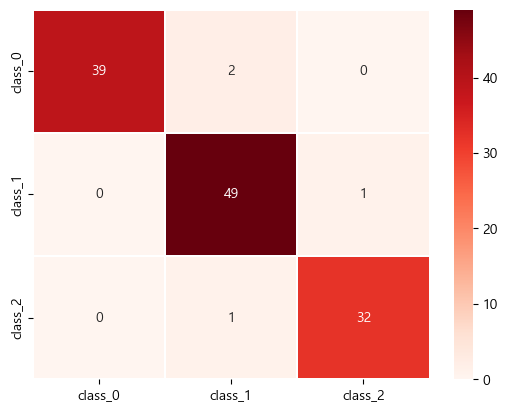

In [23]:
sb.heatmap( c_logi, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [24]:
print('정확도', accuracy_score(y_test, pred_logi_tt))
print('정밀도', precision_score(y_test, pred_logi_tt, average='macro'))
print('재현율', recall_score(y_test, pred_logi_tt, average='macro'))
print('f1 score', f1_score(y_test, pred_logi_tt, average='macro'))


정확도 0.9814814814814815
정밀도 0.9791666666666666
재현율 0.9841269841269842
f1 score 0.981117230527144


In [25]:
c_logi_t = confusion_matrix(y_test, pred_logi_tt)
c_logi_t

array([[18,  0,  0],
       [ 0, 20,  1],
       [ 0,  0, 15]])

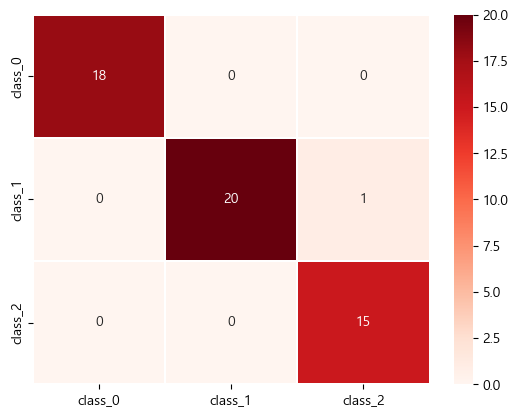

In [26]:
sb.heatmap( c_logi_t, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

## tree 측정값

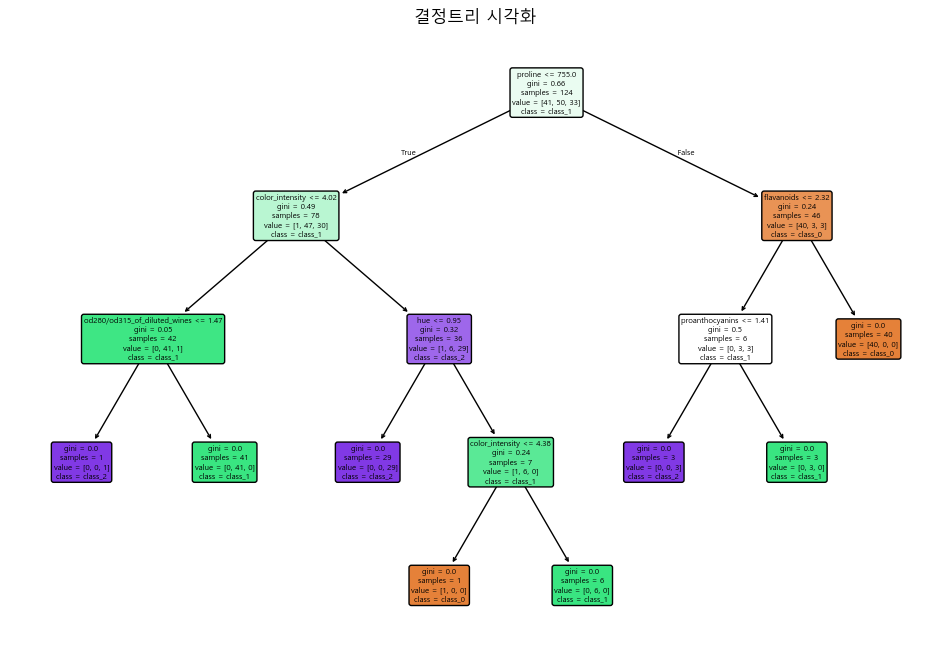

In [27]:
plt.figure(figsize=(12,8))
plot_tree(model_tree, feature_names= wine['feature_names'], class_names=wine['target_names'], filled=True, rounded=True, precision=2)
plt.title('결정트리 시각화')
plt.show()

In [28]:
# tree
print('정확도', accuracy_score(y_train, pred_tree))
print('정밀도', precision_score(y_train, pred_tree, average='macro'))
print('재현율', recall_score(y_train, pred_tree, average='macro'))
print('f1 score', f1_score(y_train, pred_tree, average='macro'))


정확도 1.0
정밀도 1.0
재현율 1.0
f1 score 1.0


In [29]:
c_tree = confusion_matrix(y_train, pred_tree)
c_tree

array([[41,  0,  0],
       [ 0, 50,  0],
       [ 0,  0, 33]])

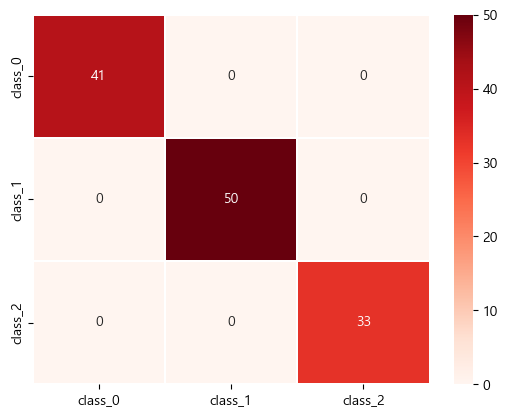

In [30]:
sb.heatmap( c_tree, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [31]:
print('정확도', accuracy_score(y_test, pred_tree_t))
print('정밀도', precision_score(y_test, pred_tree_t, average='macro'))
print('재현율', recall_score(y_test, pred_tree_t, average='macro'))
print('f1 score', f1_score(y_test, pred_tree_t, average='macro'))


정확도 0.8703703703703703
정밀도 0.8686274509803922
재현율 0.870899470899471
f1 score 0.8682781649245065


In [32]:
c_tree_t = confusion_matrix(y_test, pred_tree_t)
c_tree_t

array([[16,  0,  2],
       [ 1, 18,  2],
       [ 0,  2, 13]])

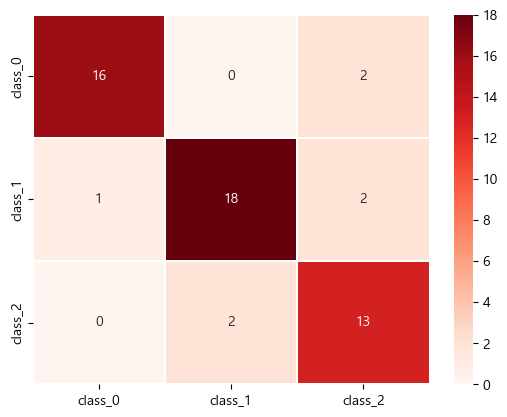

In [33]:
sb.heatmap( c_tree_t, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

## knn 측정값

In [34]:
# knn
print('정확도', accuracy_score(y_train, pred_knn))
print('정밀도', precision_score(y_train, pred_knn, average='macro'))
print('재현율', recall_score(y_train, pred_knn, average='macro'))
print('f1 score', f1_score(y_train, pred_knn, average='macro'))


정확도 0.9919354838709677
정밀도 0.9920634920634921
재현율 0.9933333333333333
f1 score 0.9926169323759685


In [35]:
c_knn = confusion_matrix(y_train, pred_knn)
c_knn

array([[41,  0,  0],
       [ 1, 49,  0],
       [ 0,  0, 33]])

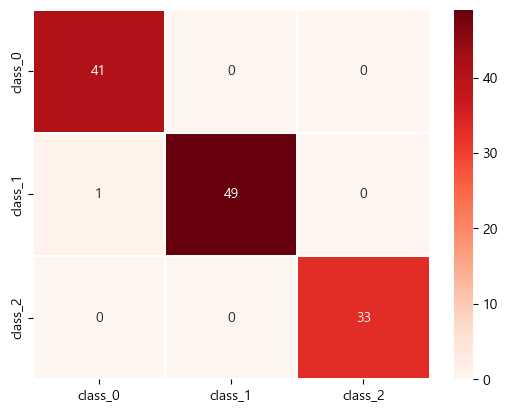

In [36]:
sb.heatmap( c_knn, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()

In [37]:
print('정확도', accuracy_score(y_test, pred_knn_t))
print('정밀도', precision_score(y_test, pred_knn_t, average='macro'))
print('재현율', recall_score(y_test, pred_knn_t, average='macro'))
print('f1 score', f1_score(y_test, pred_knn_t, average='macro'))

정확도 0.9444444444444444
정밀도 0.9432404540763674
재현율 0.9523809523809524
f1 score 0.944516632016632


In [38]:
c_knn_t = confusion_matrix(y_test, pred_knn_t)
c_knn_t

array([[18,  0,  0],
       [ 1, 18,  2],
       [ 0,  0, 15]])

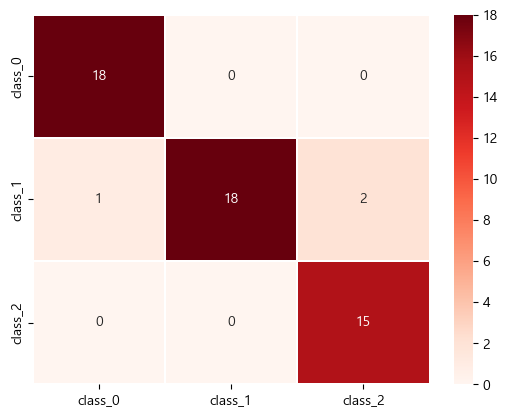

In [39]:
sb.heatmap( c_knn_t, annot=True, fmt='d',linewidths=0.2, cmap='Reds', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.show()